# 📊 Chapter 08 - Outlier Detection & Treatment

---

# 🎯 Objective

An **Outlier** is a data point that is significantly different from the rest of the observations.

Examples:

- Employee salary = ₹45,000, ₹52,000, ₹48,000, **₹15,00,000**
- Age = 22, 25, 28, **150**

Outliers can occur due to:

- Data Entry Errors
- Measurement Errors
- System Errors
- Genuine Extreme Values

If not handled properly, outliers can:

❌ Distort statistical analysis

❌ Affect Machine Learning models

❌ Produce misleading visualizations

❌ Reduce prediction accuracy

In this chapter, we will learn how to detect, visualize, and treat outliers using professional techniques.

> **Rule #1:** Never remove an outlier without understanding why it exists.

In [12]:
# ==========================================
# 📚 Import Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
# ==========================================
# 📂 Load Dataset
# ==========================================

df = pd.read_csv("dataset/employee_dirty_data.csv")

raw_df = df.copy()

# 👀 Let's Look at Salary

We'll use the **Salary** column to understand outliers.

In [14]:
# ==========================================
# Display Salary
# ==========================================

df["salary"].head(10)

0      55000
1    $45,000
2     -25000
3        75k
4        75k
5      55000
6    $45,000
7    $45,000
8        75k
9     -25000
Name: salary, dtype: str

# 📊 Summary Statistics

Before detecting outliers, let's understand the data distribution.

### Syntax

```python
Series.describe()
```

In [15]:
# ==========================================
# Salary Statistics
# ==========================================

df["salary"].describe()

count     100
unique      4
top       75k
freq       48
Name: salary, dtype: object

# 📦 Visualize Outliers using Box Plot

A Box Plot is the quickest way to identify possible outliers.

Values outside the whiskers are potential outliers.

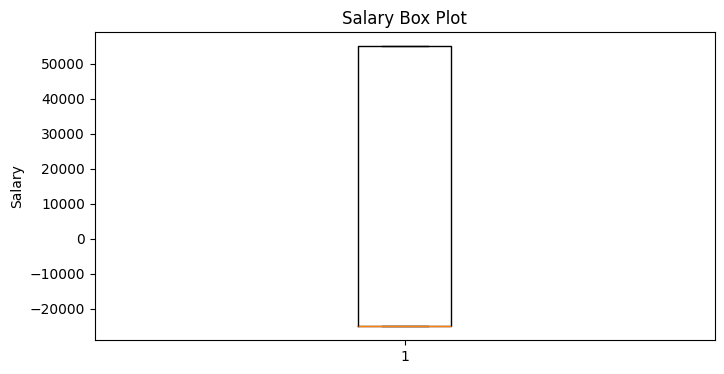

In [16]:
# ==========================================
# Clean Salary Column
# ==========================================

df["salary"] = (
    df["salary"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df["salary"] = pd.to_numeric(
    df["salary"],
    errors="coerce"
)

# ==========================================
# Box Plot
# ==========================================

plt.figure(figsize=(8,4))

plt.boxplot(df["salary"].dropna())

plt.title("Salary Box Plot")

plt.ylabel("Salary")

plt.show()

# 📈 Detect Outliers using IQR Method

IQR (Interquartile Range) is the most commonly used method for detecting outliers.

### Formula

```
IQR = Q3 - Q1

Lower Limit = Q1 - 1.5 × IQR

Upper Limit = Q3 + 1.5 × IQR
```

In [17]:
# ==========================================
# Calculate IQR
# ==========================================

Q1 = df["salary"].quantile(0.25)

Q3 = df["salary"].quantile(0.75)

IQR = Q3 - Q1

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR:", IQR)  

Q1 : -25000.0
Q3 : 55000.0
IQR: 80000.0


In [18]:
# ==========================================
# Calculate Lower & Upper Limits
# ==========================================

lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR

print("Lower Limit :", lower_limit)

print("Upper Limit :", upper_limit)

Lower Limit : -145000.0
Upper Limit : 175000.0


In [19]:
 # ==========================================
# Find Outliers
# ==========================================

outliers = df[
    (df["salary"] < lower_limit) |
    (df["salary"] > upper_limit)
]

outliers

,employee_id,full_name,gender,age,email,phone,department,designation,salary,bonus,...,city,state,country,zipcode,performance_score,attendance,is_active,project_count,manager,remarks


# 🔢 Count Outliers

In [20]:
# ==========================================
# Number of Outliers
# ==========================================

len(outliers)

# ==========================================
# Percentage of Outliers
# ==========================================

(len(outliers) / len(df)) * 100

0.0

# 🗑️ Remove Outliers

Sometimes extreme values are incorrect and can be removed.

In [21]:
# ==========================================
# Remove Outliers
# ==========================================

clean_df = df[
    (df["salary"] >= lower_limit) &
    (df["salary"] <= upper_limit)
]

clean_df.head()

# ==========================================
# Dataset Shape Before & After
# ==========================================

print("Original :", df.shape)

print("After Removing :", clean_df.shape)

Original : (100, 23)
After Removing : (33, 23)


# ✂️ Cap Outliers (Clipping)

Instead of deleting outliers, we can replace them with boundary values.

This technique preserves the number of records.

In [22]:
# ==========================================
# Clip Salary Values
# ==========================================

temp_df = df.copy()

temp_df["salary"] = temp_df["salary"].clip(
    lower=lower_limit,
    upper=upper_limit
)

temp_df.head()

,employee_id,full_name,gender,age,email,phone,department,designation,salary,bonus,...,city,state,country,zipcode,performance_score,attendance,is_active,project_count,manager,remarks
0,1001,John Smith,Male,28,john@gmail.com,9876543210,HR,Analyst,55000.0,5000.0,...,Mumbai,Maharashtra,India,400001,8.5,95,Yes,3.0,Rahul Sharma,Good Employee
1,1002,John Doe,male,Thirty,johndoe@gmail,98765,hr,Data Analyst,NaN,NaN,...,mumbai,MH,IND,4000A,11.0,105,TRUE,NaN,Amit,
2,1003,Alice@@ Brown,F,-25,alice@@gmail.com,ABCDE12345,Human Resource,Developer,-25000.0,2500.0,...,Pune,Maharashtra,india,411001,-5.0,-15,1,2.0,Suresh,Excellent
3,1004,Bob Lee,MALE,35,NaN,999999999999,Finance,Manager,NaN,6000.0,...,Delhi,Delhi,INDIA,110001,9.2,98,Y,5.0,Priya,Promoted
4,1004,Bob Lee,MALE,35,NaN,999999999999,Finance,Manager,NaN,6000.0,...,Delhi,Delhi,INDIA,110001,9.2,98,Y,5.0,Priya,Promoted


# 📊 Compare Before & After

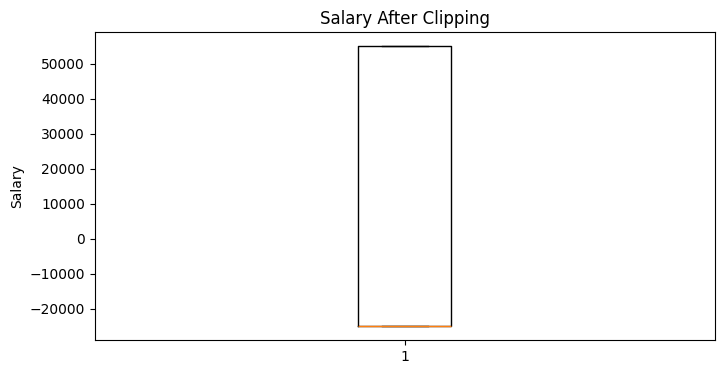

In [23]:
# ==========================================
# Box Plot Comparison
# ==========================================

plt.figure(figsize=(8,4))

plt.boxplot(temp_df["salary"].dropna())

plt.title("Salary After Clipping")

plt.ylabel("Salary")

plt.show()

# 📈 Detect Outliers using Z-Score

Z-Score measures how far a value is from the mean.

A common rule:

- Z > 3 → Outlier
- Z < -3 → Outlier

In [24]:
# ==========================================
# Calculate Z-Score
# ==========================================

temp_df = df.copy()

mean = temp_df["salary"].mean()

std = temp_df["salary"].std()

temp_df["z_score"] = (
    temp_df["salary"] - mean
) / std

temp_df.head()

,employee_id,full_name,gender,age,email,phone,department,designation,salary,bonus,...,state,country,zipcode,performance_score,attendance,is_active,project_count,manager,remarks,z_score
0,1001,John Smith,Male,28,john@gmail.com,9876543210,HR,Analyst,55000.0,5000.0,...,Maharashtra,India,400001,8.5,95,Yes,3.0,Rahul Sharma,Good Employee,1.147178
1,1002,John Doe,male,Thirty,johndoe@gmail,98765,hr,Data Analyst,NaN,NaN,...,MH,IND,4000A,11.0,105,TRUE,NaN,Amit,,NaN
2,1003,Alice@@ Brown,F,-25,alice@@gmail.com,ABCDE12345,Human Resource,Developer,-25000.0,2500.0,...,Maharashtra,india,411001,-5.0,-15,1,2.0,Suresh,Excellent,-0.845289
3,1004,Bob Lee,MALE,35,NaN,999999999999,Finance,Manager,NaN,6000.0,...,Delhi,INDIA,110001,9.2,98,Y,5.0,Priya,Promoted,NaN
4,1004,Bob Lee,MALE,35,NaN,999999999999,Finance,Manager,NaN,6000.0,...,Delhi,INDIA,110001,9.2,98,Y,5.0,Priya,Promoted,NaN


In [25]:
# ==========================================
# Find Z-Score Outliers
# ==========================================

temp_df[
    temp_df["z_score"].abs() > 3
]

,employee_id,full_name,gender,age,email,phone,department,designation,salary,bonus,...,state,country,zipcode,performance_score,attendance,is_active,project_count,manager,remarks,z_score


# 📋 Outlier Treatment Cheat Sheet

| Method | Best For |
|---------|----------|
| Box Plot | Quick Visualization |
| IQR | Skewed Data |
| Z-Score | Normally Distributed Data |
| Remove | Incorrect Values |
| Clip | Preserve Dataset Size |

# 📌 Chapter 08 Complete ✅

Congratulations! 🎉

You have learned professional techniques to detect and treat outliers.

## Functions & Concepts Covered

- `describe()`
- `quantile()`
- `boxplot()`
- `clip()`
- IQR Method
- Lower & Upper Limits
- Z-Score Method
- Outlier Removal
- Outlier Clipping

In the next chapter, we'll learn **✅ Data Validation & Quality Checks**, where we'll perform final checks to ensure our cleaned dataset is complete, consistent, and ready for analysis or machine learning.